In [76]:
import ee
# from rich.jupyter import display
# from sympy.stats.sampling.sample_numpy import numpy

ee.Authenticate()

True

In [77]:
ee.Initialize(project="climateconsciousimli")  # assumes you've authenticated already

In [78]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
# import torch
import numpy as np

In [97]:
# Define bounding box (lon_min, lat_min, lon_max, lat_max)
lat_min, lat_max = 28.0, 29.39
lat_avg = (lat_max + lat_min) / 2
lon_min, lon_max = 76.3, 79.0
lon_avg = (lon_max + lon_min) / 2

stepp = 0.25


roi = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])
pixel = ee.Geometry.Point([77.0, 29.0])
micropixel = ee.Geometry.Rectangle([lon_avg-stepp, lat_avg-stepp, lon_avg+stepp, lat_avg+stepp])
sampling_scale = 5000
start_date = '2024-02-03'
end_date = '2024-02-05'

- Everything is the same till now.
- `scale` is \~8km.
- `pixel` is one point.
- `roi` is the region.
- `micropixel` is a smaller region to make computation easier
- Now collect the data accordingly :

In [98]:
"""
Can define multiple collections (wind, SO2, NO2). Prepare what we're doing for each. Then feed outputs for all. No merging required as such, except right before training/input into a model.
"""

collection = (
    ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2")
    .filterBounds(roi)# REPLACE WITH ROI
    .filterDate(start_date, end_date)
    .select('tropospheric_NO2_column_number_density')
)

- The function `make_coarse` given below is of interest. In words (which I myself don't fully understand yet), it takes in raw data, reduces its resolution by taking a mean (how is that done/executed?). It then "reprojeccts" the data, with some scale in mind, giving us the "coarse" data.
- The raw data has each pixel representing ~7km$^2$. We do not wish to work with this. To "access" the data, we call several functions :
-   `reduceResolution`
-   `reproject` onto the grid.
-   `focal_mean` : treat "Null" by taking a spatial mean.
-   `copyProperties` : preserves `system:time_start`.

In [99]:
def make_coarse(image):
    return (image
        .reduceResolution(
            reducer=ee.Reducer.mean(),
            bestEffort=True
        )
        .reproject(
            scale=1100,
            crs='EPSG:4326'
        )#.focal_mean(radius=1, units='pixels')
        .copyProperties(image, ['system:time_start'])
    )

coarse_collection = collection.map(make_coarse) # This (possibly coarse) collection will be henceforth be used.

size_of_coll = coarse_collection.size().getInfo()
print(f"Size of collection is {size_of_coll}. In particular, coarse_collection.getInfo()['features'] has that many items.")
print()
print(f"This means we have ~{size_of_coll} entries in the given time range. For each of these, we have an image (11px by 11px) of the entire region we have (after reducing resolution) So if we have {size_of_coll} measurements for the region, and the region is (say) 11*11 pixels, then we have ~{11*11*size_of_coll} measurements. Many of these may be null!")
# print(coarse_collection.first().getInfo()['properties']['system:time_start']) # need to parse as date-time

Size of collection is 28. In particular, coarse_collection.getInfo()['features'] has that many items.

This means we have ~28 entries in the given time range. For each of these, we have an image (11px by 11px) of the entire region we have (after reducing resolution) So if we have 28 measurements for the region, and the region is (say) 11*11 pixels, then we have ~3388 measurements. Many of these may be null!


In [100]:
def sample_image(image):
    samples = image.sample(
        region=roi,
        scale=sampling_scale,
        geometries=True,
        dropNulls=True
    )
    # return samples.map(lambda f: f.set('system:time_start', f.getInfo()['properties']['system:time_start'])).map(lambda f: f.set(
    #     'date', image.date().format('YYYY-MM-dd')
    # ))
    time_start = image.get('system:time_start')
    return samples.map(lambda f: f.set({
        # 'system:time_start': time_start,
        'date': ee.Date(time_start).format('YYYY-MM-dd'),
        'datetime': ee.Date(time_start).format('YYYY-MM-dd HH:mm:ss')
    }))

fc = coarse_collection.map(sample_image).flatten()
print(f"Now we have reduced our region of interest from roi to micropixel or pixel. We retain null values and the data we keep is as below :")

Now we have reduced our region of interest from roi to micropixel or pixel. We retain null values and the data we keep is as below :


In [101]:
features = fc.getInfo()['features']
# print(f"Features are : \n\n{features}\n\n")
proppies = features[0]['properties'] # ['tropospheric_NO2_column_number_density'])
print(f"Following is 'fc.getInfo()['features'][0]['properties']', that is, the properties relating to the first (hence `0`) feature that we have. One can expect to see date, date-time, and NO2 value (if not null) : \n\n{proppies}\n\n")
print()
print(f"proppies.get('tropospheric_NO2_column_number_density') gives {proppies.get('tropospheric_NO2_column_number_density')}")
print("This applies for proppies being the first record in the given time range. Now we will try them all out ....\n\n\n")


n_feature_instances = len(features)
print(f"number of 'features' is {n_feature_instances}, as we calculated above.")
print(features[0].get('properties'))
for i in range(n_feature_instances):
    print(features[i]['properties'].get('tropospheric_NO2_column_number_density'), features[i]['properties'].get('datetime'))
# for j in proppies:
#     print(j)
#     print()

Following is 'fc.getInfo()['features'][0]['properties']', that is, the properties relating to the first (hence `0`) feature that we have. One can expect to see date, date-time, and NO2 value (if not null) : 

{'date': '2024-02-03', 'datetime': '2024-02-03 07:49:22', 'tropospheric_NO2_column_number_density': 3.951900705843573e-05}



proppies.get('tropospheric_NO2_column_number_density') gives 3.951900705843573e-05
This applies for proppies being the first record in the given time range. Now we will try them all out ....



number of 'features' is 1074, as we calculated above.
{'date': '2024-02-03', 'datetime': '2024-02-03 07:49:22', 'tropospheric_NO2_column_number_density': 3.951900705843573e-05}
3.951900705843573e-05 2024-02-03 07:49:22
3.9519006602309186e-05 2024-02-03 07:49:22
4.389884061593955e-05 2024-02-03 07:49:22
5.805446122851258e-05 2024-02-03 07:49:22
6.244904277462912e-05 2024-02-03 07:49:22
5.585903636531202e-05 2024-02-03 07:49:22
5.5523761693288565e-05 2024-02-03 07:49:2

## Clean representation of data available
- Below, we store the data that the satellite measured/observed in a `pandas` dataframe.
- With this, we can move onto the task of temporal interpolation, which isn't built into GEE, but in pandas.

In [102]:
features = fc.getInfo()['features']

rows = []
for f in features:
    props = f['properties']
    coords = f['geometry']['coordinates']

    if 'tropospheric_NO2_column_number_density' in props:
        rows.append({
            'lon': coords[0],
            'lat': coords[1],
            'date': props['date'],
            'datetime': props['datetime'],
            'NO2': props['tropospheric_NO2_column_number_density']
        })

df = pd.DataFrame(rows)
df

,lon,lat,date,datetime,NO2
0,77.052993,29.352452,2024-02-03,2024-02-03 07:49:22,0.000040
1,77.097909,29.352452,2024-02-03,2024-02-03 07:49:22,0.000040
2,77.142825,29.352452,2024-02-03,2024-02-03 07:49:22,0.000044
3,77.187741,29.352452,2024-02-03,2024-02-03 07:49:22,0.000058
4,77.232657,29.352452,2024-02-03,2024-02-03 07:49:22,0.000062
...,...,...,...,...,...
1069,77.052993,28.454137,2024-02-04,2024-02-04 07:30:24,0.000136
1070,76.783499,28.409221,2024-02-04,2024-02-04 07:30:24,0.000060
1071,76.828415,28.409221,2024-02-04,2024-02-04 07:30:24,0.000083
1072,77.052993,28.409221,2024-02-04,2024-02-04 07:30:24,0.000080


In [103]:
unique_dates = sorted(df['date'].unique())
# print(len(df['date']))
selected_dates = unique_dates[:]
# """
#     This is needed to plot the images of those dates for which we have data
# """

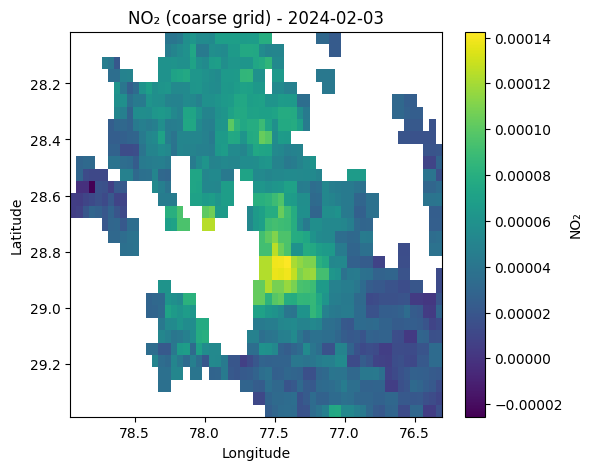

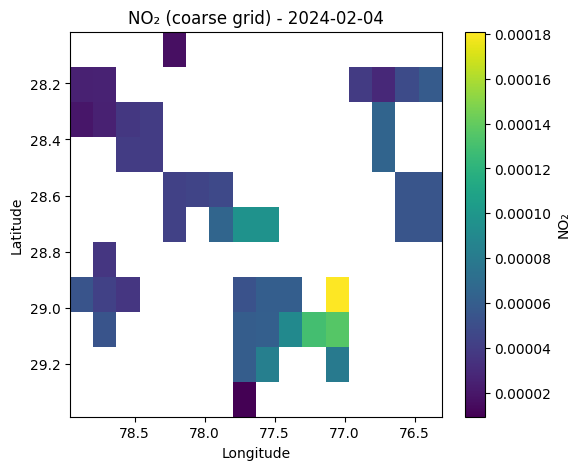

In [104]:
latt = []
lonn = []

for d in selected_dates:
    subset = df[df['date'] == d].copy()

    # Create grid
    pivot = subset.pivot_table(
        index='lat',
        columns='lon',
        values='NO2'
    )
    pivot.fillna(0)

    plt.figure(figsize=(6,5))
    plt.imshow(
        pivot.values,
        extent=(
            78.96056600117977, 76.30334939075422,
            29.38973199289633, 28.015309608193462
            # # Hardcoded in order to avoid the case where the image is zoomed in because all border pixels (or all along horizontal edges, for example) are missing
            # pivot.columns.min(), pivot.columns.max(),
            # pivot.index.min(), pivot.index.max()
        ),
        origin='lower',
        aspect='auto'
    )
    # lonn += [pivot.columns.min(), pivot.columns.max()]
    # latt += [pivot.index.min(), pivot.index.max()]
    # # A mechanism to find the widest and tallest swath seen by the satellite, helps hardcode the graph limits.
    plt.colorbar(label='NO₂')
    plt.title(f'NO₂ (coarse grid) - {d}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

# print(max(latt), min(latt))
# print(max(lonn), min(lonn))

In [105]:
# make a copy and ensure date types
df_interp = df.copy()
df_interp['date'] = pd.to_datetime(df_interp['date'])

# create a complete grid. all lats * all lons * all dates
# this can blow up in size fast
# May limit days to ~3 or ~5 for training.
all_lats = df_interp['lat'].unique()
all_lons = df_interp['lon'].unique()
all_times = sorted(df_interp['date'].unique())


index = pd.MultiIndex.from_product([all_lats, all_lons, all_times], names=['lat', 'lon', 'date'])
full_df = pd.DataFrame(index=index)

# Merge original data. `left` tells us what is written (df_interp) onto what (full_df)
df_merged = pd.merge(full_df, df_interp, on=['lat', 'lon', 'date'], how='left')
df_merged = df_merged.sort_values(['lat', 'lon', 'date'])


# Now df_merged is full-size, containing all observed values. Now we perform interpolation without fearing the absence of some lat-lon-date triplet!

# interpolate NO2
df_merged['NO2_interpolated'] = df_merged.groupby(['lat', 'lon'])['NO2'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both', limit=1)#.bfill().ffill() # Can fill fwd/bkwd. Can increase limit, but that blurs too much.
)

print("Original row count:", len(df['NO2']))
print("Expanded row count:", len(df_merged['NO2_interpolated']))
print(f"Number of usable (not NaN) entries of NO2 (observed), and of NO2_interpolated are : {int(df_merged['NO2'].count())}, {int(df_merged['NO2_interpolated'].count())}, respectively.")

Original row count: 1074
Expanded row count: 3720
Number of usable (not NaN) entries of NO2 (observed), and of NO2_interpolated are : 1074, 2104, respectively.


In [106]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def spatial_mean_transform(series, lat, lon, radius=0.02):
    """
    series: pd.Series of NO2 values
    lat, lon: pd.Series of coordinates
    radius: neighborhood radius (in coordinate units)
    """
    values = series.values
    coords = np.column_stack([lat.values, lon.values])
    
    # Fit nearest neighbors
    nn = NearestNeighbors(radius=radius)
    nn.fit(coords)
    
    neighbors = nn.radius_neighbors(coords, return_distance=False)
    
    interpolated = np.empty_like(values, dtype=float)
    
    for i, inds in enumerate(neighbors):
        known_vals = values[inds][~np.isnan(values[inds])]
        if len(known_vals) > 0:
            interpolated[i] = known_vals.mean()
        else:
            interpolated[i] = np.nan
            
    return interpolated

# Now use it with groupby().transform()
# df_s['NO2_interpolated'] = df_s.groupby('date').transform(
#     lambda g: spatial_mean_transform(g['NO2'], g['lat'], g['lon'], radius=0.02)
# )['NO2']

In [107]:
# make a copy and ensure date types
df_interp_s = df_interp.copy() # CHANGED THIS TO DF_INTERP, WAS DF BEFORE. KEEP DF LATER. JUST CHECKING.
df_interp_s['date'] = pd.to_datetime(df_interp_s['date'])

# create a complete grid. all lats * all lons * all dates
# this can blow up in size fast
# May limit days to ~3 or ~5 for training.
all_lats = df_interp_s['lat'].unique()
all_lons = df_interp_s['lon'].unique()
all_times = sorted(df_interp_s['date'].unique())


index = pd.MultiIndex.from_product([all_lats, all_lons, all_times], names=['lat', 'lon', 'date'])
full_df_s = pd.DataFrame(index=index)

# Merge original data. `left` tells us what is written (df_interp_s) onto what (full_df)
df_merged_s = pd.merge(full_df_s, df_interp_s, on=['lat', 'lon', 'date'], how='left')
df_merged_s = df_merged_s.sort_values(['lat', 'lon', 'date'])


# Now df_merged_s is full-size, containing all observed values. Now we perform interpolation without fearing the absence of some lat-lon-date triplet!

# interpolate NO2 spatially. THIS IS NOT ENOUGH. NEEDS TO BE SENSITIVE TO THE SPATIAL ARRANGEMENT. NEED ANOTHER LIBRARY FOR THIS. WILL DO THAT LATER.
# df_merged_s['NO2_interpolated'] = df_merged_s.groupby(['date'])['NO2'].transform(
#     lambda x: x.interpolate(method='linear', limit_direction='both', limit=20)#.bfill().ffill() # Can fill fwd/bkwd. Can increase limit, but that blurs too much.
# )
df_merged_s['NO2_interpolated'] = df_merged_s.groupby('date').apply(
    lambda g: spatial_mean_transform(g['NO2'], g['lat'], g['lon'], radius=0.07)
).explode().astype(float).values

print("Original row count:", len(df['NO2']))
print("Expanded row count:", len(df_merged_s['NO2_interpolated']))
print(f"Number of usable (not NaN) entries of NO2 (observed), and of NO2_interpolated are : {int(df_merged_s['NO2'].count())}, {int(df_merged_s['NO2_interpolated'].count())}, respectively.")
df_merged_s

Original row count: 1074
Expanded row count: 3720
Number of usable (not NaN) entries of NO2 (observed), and of NO2_interpolated are : 1074, 1496, respectively.


,lat,lon,date,datetime,NO2,NO2_interpolated
3718,28.004979,76.334341,2024-02-03,NaN,NaN,NaN
3719,28.004979,76.334341,2024-02-04,NaN,NaN,NaN
3708,28.004979,76.379257,2024-02-03,NaN,NaN,NaN
3709,28.004979,76.379257,2024-02-04,NaN,NaN,NaN
3690,28.004979,76.424173,2024-02-03,NaN,NaN,NaN
...,...,...,...,...,...,...
87,29.352452,78.894540,2024-02-04,NaN,NaN,NaN
84,29.352452,78.939456,2024-02-03,NaN,NaN,NaN
85,29.352452,78.939456,2024-02-04,NaN,NaN,NaN
88,29.352452,78.984371,2024-02-03,NaN,NaN,NaN


## Interpolation successful?
- We have improved the amount of data available, with reasonable practices.
- Ideally, we would like to allow for more interesting relations temporally and spatially. Something like a convolution is more what we are looking for. Diffusion models also would work well to predict the change in these "images", as we are essentially "painting in the data".
- Below is a view of the data post-interpolation.

            lat        lon       date datetime  NO2  NO2_interpolated
3718  28.004979  76.334341 2024-02-03      NaN  NaN               NaN
3719  28.004979  76.334341 2024-02-04      NaN  NaN               NaN
3708  28.004979  76.379257 2024-02-03      NaN  NaN               NaN
3709  28.004979  76.379257 2024-02-04      NaN  NaN               NaN
3690  28.004979  76.424173 2024-02-03      NaN  NaN               NaN
...         ...        ...        ...      ...  ...               ...
87    29.352452  78.894540 2024-02-04      NaN  NaN               NaN
84    29.352452  78.939456 2024-02-03      NaN  NaN               NaN
85    29.352452  78.939456 2024-02-04      NaN  NaN               NaN
88    29.352452  78.984371 2024-02-03      NaN  NaN               NaN
89    29.352452  78.984371 2024-02-04      NaN  NaN               NaN

[3720 rows x 6 columns]


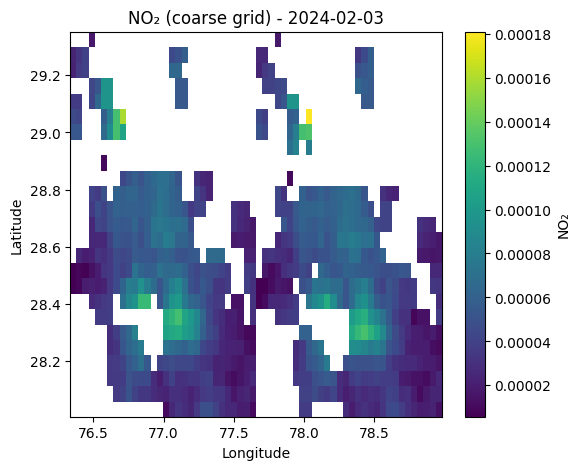

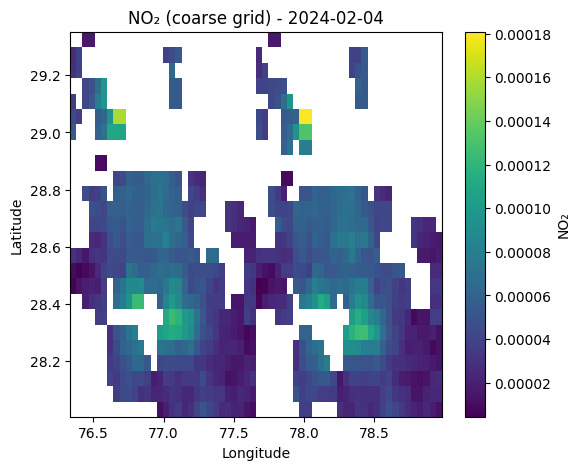

In [108]:
# latt = []
# lonn = []
print(df_merged_s)
for d in selected_dates:
    subset = df_merged_s[df_merged_s['date'] == d].copy()

    # Create grid
    pivot = subset.pivot_table(
        index='lat',
        columns='lon',
        values='NO2_interpolated'
    )
    pivot.fillna(0.0)

    plt.figure(figsize=(6,5))
    plt.imshow(
        pivot.values,
        extent=(
            # 78.96056600117977, 76.30334939075422,
            # 29.38973199289633, 28.015309608193462
            pivot.columns.min(), pivot.columns.max(),
            pivot.index.min(), pivot.index.max()
        ),
        origin='lower',
        aspect='auto'
    )
    lonn += [pivot.columns.min(), pivot.columns.max()]
    latt += [pivot.index.min(), pivot.index.max()]
    plt.colorbar(label='NO₂')
    plt.title(f'NO₂ (coarse grid) - {d}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

# print(max(latt), min(latt))
# print(max(lonn), min(lonn))

### Focal mean too early
- Taking a focal mean (performing spatial interpolation) introduces artifacts in the images that appears misleading at least to the human eye. Whether it makes a difference (or rather, what kind of a difference it would make) to a CNN being trained on the data is unclear and pending investigation.

            lat        lon       date datetime  NO2  NO2_interpolated
3718  28.004979  76.334341 2024-02-03      NaN  NaN               NaN
3719  28.004979  76.334341 2024-02-04      NaN  NaN               NaN
3708  28.004979  76.379257 2024-02-03      NaN  NaN               NaN
3709  28.004979  76.379257 2024-02-04      NaN  NaN               NaN
3690  28.004979  76.424173 2024-02-03      NaN  NaN               NaN
...         ...        ...        ...      ...  ...               ...
87    29.352452  78.894540 2024-02-04      NaN  NaN               NaN
84    29.352452  78.939456 2024-02-03      NaN  NaN               NaN
85    29.352452  78.939456 2024-02-04      NaN  NaN               NaN
88    29.352452  78.984371 2024-02-03      NaN  NaN               NaN
89    29.352452  78.984371 2024-02-04      NaN  NaN               NaN

[3720 rows x 6 columns]


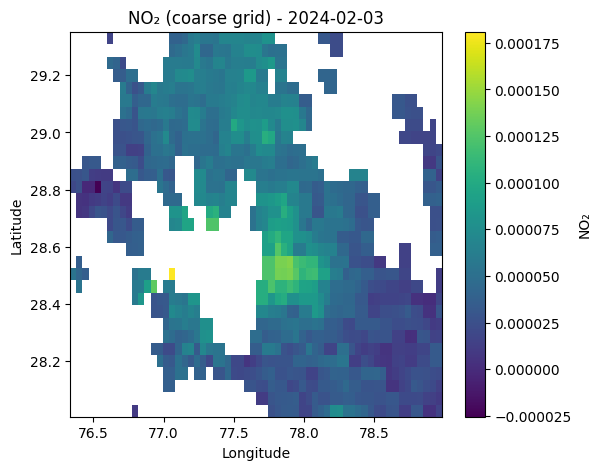

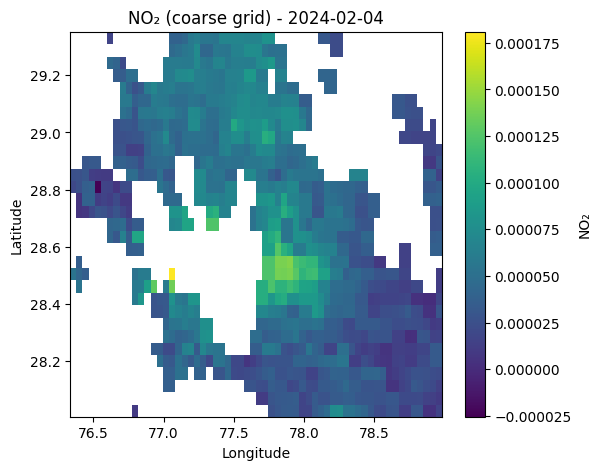

In [109]:
# latt = []
# lonn = []
print(df_merged)
for d in selected_dates:
    subset = df_merged[df_merged['date'] == d].copy()

    # Create grid
    pivot = subset.pivot_table(
        index='lat',
        columns='lon',
        values='NO2_interpolated'
    )
    pivot.fillna(0.0)

    plt.figure(figsize=(6,5))
    plt.imshow(
        pivot.values,
        extent=(
            # 78.96056600117977, 76.30334939075422,
            # 29.38973199289633, 28.015309608193462
            pivot.columns.min(), pivot.columns.max(),
            pivot.index.min(), pivot.index.max()
        ),
        origin='lower',
        aspect='auto'
    )
    lonn += [pivot.columns.min(), pivot.columns.max()]
    latt += [pivot.index.min(), pivot.index.max()]
    plt.colorbar(label='NO₂')
    plt.title(f'NO₂ (coarse grid) - {d}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

# print(max(latt), min(latt))
# print(max(lonn), min(lonn))